# Analyse results from Pypsa-Earth
This notebook reads the latest optimization described in the config.yaml file and makes plots and summaries of the results.

Sources: 
- Plot capacity - map view: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/viz/regional_transm_system_viz.ipynb
- Analyse energy potential: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/build_renewable_profiles.ipynb
- Analyse energy generation: https://pypsa.readthedocs.io/en/latest/examples/statistics.html

Some files are needed:
* PyPSA network file (e.g. "elec.nc" contains a lot of details and looks perfect)
* a country shape file (may be found in "resources/shapes/country_shapes.geojson")
* a renewable profile file (may be found in "resources/renewable_profiles/....nc)

## Import packages

In [2]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy

In [3]:
warnings.simplefilter(action='ignore', category=FutureWarning)
# change current directory to parent folder
if not os.path.isdir("pypsa-earth"):
    os.chdir("../..")

PARENT = os.path.realpath("pypsa-earth/") + "/"
# Specify config name
# CONFIG = "config-EG-sec-2050-0_50_100_200_300_400_800_1000TWh"
CONFIG = "config-EG-50percentCO2-2050-50-1000TWh"
# CONFIG = 'config-EG-sec-24H-CO2_0.7_0.5_0.2_0.1_0-0_107TWh'
config = yaml.safe_load(open(PARENT + "own-configs/" + CONFIG + ".yaml"))

# Specify name for figures
overall_name = 'v1_EG_CO2-50-100perc_reduction_0-107_TWh-Export'
# Specify of you want to save the figures
save_figs = False

In [4]:
run_name = config["run"]["name"]
run_sector_name = config["run"]["sector_name"]                          
simpl = config["scenario"]["simpl"]    
clust = config["scenario"]["clusters"]   
ll = config["scenario"]["ll"]             
load_scale = config["load_options"]["scale"]               
opts = config["scenario"]["opts"]       
sopts = config["scenario"]["sopts"]              
planning = config["scenario"]["planning_horizons"]        
discountrate = config["costs"]["discountrate"]                
demand = config["scenario"]["demand"]                  
# export_value = config["export"]["h2export"]  
export_value = [107]                

# Process each setting into a string representation 
simpl_str = "_".join(map(str, simpl))   
clust_str = "_".join(map(str, clust))    
ll_str = "l" + "_".join(map(str, ll))           
scale_str = f"lc{load_scale}"                           
opts_str = "_".join(map(str, opts))    
sopts_str = "_".join(map(str, sopts))                 
planning_str = "_".join(map(str, planning))               
dr_str = "_".join(map(str, discountrate))             
demand_str = "_".join(map(str, demand))                    
export_str = "_".join(map(str, export_value)) + "export"

scenario_subpath = f"{run_name}/" if run_name else ""

nc_file_name = (
    f"elec_s_{clust_str}_ec_{ll_str}_{opts_str}_{sopts_str}_"
    f"{planning_str}_{dr_str}_{demand_str}_{export_str}.nc"
)

# Network file
network_path = PARENT + f"networks/{scenario_subpath}elec.nc"

# Country shape file
regions_onshore_path = PARENT + f"resources/{scenario_subpath}shapes/country_shapes.geojson"

# Bus_regions_file
bus_regions = PARENT + f"resources/{scenario_subpath}bus_regions/regions_onshore.geojson"

# GADM shapes file
gadm_shapes_path = PARENT + f"resources/{scenario_subpath}/shapes/gadm_shapes.geojson"

# Results path
results_path = PARENT + f"results/{run_sector_name}/postnetworks/{nc_file_name}"

# Renewable profile file
solar_path = PARENT + f"resources/{scenario_subpath}renewable_profiles/profile_solar.nc"
onwind_path = PARENT + f"resources/{scenario_subpath}renewable_profiles/profile_onwind.nc"

## Analysis Network Setup

In [5]:
warnings.simplefilter(action='ignore', category=FutureWarning)
# n = pypsa.Network(results_path)
n = pypsa.Network('pypsa-earth/results/EG-sec-WS/postnetworks/elec_s_8_ec_lcopt_Co2L0-3H_24H_2050_0.071_NZ_107export.nc')
regions_onshore = gpd.read_file(regions_onshore_path)
bus_regions = gpd.read_file(bus_regions)
# New
gadm_shapes = gpd.read_file(gadm_shapes_path)
gadm_shapes = gadm_shapes.set_index('GADM_ID')
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]
warnings.simplefilter(action='default', category=FutureWarning)

Index(['CO2 pipeline EG.10_1_AC <-> EG.18_1_AC',
       'CO2 pipeline EG.10_1_AC <-> EG.19_1_AC',
       'CO2 pipeline EG.10_1_AC <-> EG.2_1_AC',
       'CO2 pipeline EG.10_1_AC <-> EG.8_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.12_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.15_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.16_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.19_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.8_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.16_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.1_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.5_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.8_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.9_1_AC',
       'CO2 pipeline EG.13_1_AC <-> EG.25_1_AC',
       'CO2 pipeline EG.14_1_AC <-> EG.17_1_AC',
       'CO2 pipeline EG.14_1_AC <-> EG.25_1_AC',
       'CO2 pipeline EG.15_1_AC <-> EG.19_1_AC',
       'CO2 pipeline EG.15_1_AC <-> EG.22_1_AC',
       'CO2 pipeline EG.15_1_AC <-> EG.26_1_AC',
       'CO2 pipeline EG.15_

## Data import check

Plot of the region of interest

In [6]:
# fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
# with plt.rc_context({"patch.linewidth": 0.}):
#     regions_onshore.plot(
#     ax=ax,
#     facecolor="green",
#     edgecolor="white",
#     aspect="equal",
#     transform=ccrs.PlateCarree(),
#     linewidth=0,
#     )
# ax.set_title(", ".join(regions_onshore.name.values))

List number of components by type

In [7]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 574 entries
Component 'Carrier' has 38 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 56 entries
Component 'LineType' has 35 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 1517 entries
Component 'Load' has 795 entries
Component 'Generator' has 912 entries
Component 'StorageUnit' has 3 entries
Component 'Store' has 355 entries


List the snapshots of the PyPSA network

In [8]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10',
               ...
               '2013-12-22', '2013-12-23', '2013-12-24', '2013-12-25',
               '2013-12-26', '2013-12-27', '2013-12-28', '2013-12-29',
               '2013-12-30', '2013-12-31'],
              dtype='datetime64[ns]', name='snapshot', length=365, freq=None)
Time steps: 365


## Analyse energy system

In [9]:
n.carriers.loc[n.carriers.color.isnull() | (n.carriers.color == "#11111"), "color"] = "#d3d3d3"
n.carriers.color

Carrier
nuclear                                      #ff9000
CCGT                                         #b80404
geothermal                                   #ba91b1
hydro                                        #08ad97
offwind-ac                                   #6895dd
offwind-dc                                   #74c6f2
onwind                                       #235ebc
solar                                        #f9d002
PHS                                          #08ad97
ror                                          #4adbc8
co2                                                 
gas                                                 
oil                                                 
coal                                                
lignite                                             
biomass                                             
H2                                                  
battery                                             
residential rural heat                

### Analyse the current capacity of the energy system - map view

Set relevant carriers and colors

In [10]:
# TODO: Ensure that every carrier has a color and a nice name in the config, then we can delete this code cell
# --- Ensure all carriers have color and nice_name ---
missing_carriers = [
    'lignite', 'coal', 'solar rooftop', 'oil', 'gas',
    'residential rural solar thermal',
    'residential urban decentral solar thermal',
    'services rural solar thermal',
    'services urban decentral solar thermal',
    'urban central solar thermal',
    'ccgt'
]

carrier_color_mapping = {
    'lignite': 'coal',
    'solar rooftop': 'solar',
    'residential rural solar thermal': 'solar',
    'residential urban decentral solar thermal': 'solar',
    'services rural solar thermal': 'solar',
    'services urban decentral solar thermal': 'solar',
    'urban central solar thermal': 'solar',
    'ccgt': 'gas'
}

# Assign colors for missing carriers
for c, ref in carrier_color_mapping.items():
    n.carriers.loc[c, 'color'] = n.carriers.loc[ref, 'color']

# Set nice_names
n.carriers.loc['coal', 'nice_name'] = 'Coal'
n.carriers.loc['oil', 'nice_name'] = 'Oil'
n.carriers.loc['ccgt', 'nice_name'] = 'Gas'

for c, ref in carrier_color_mapping.items():
    if c not in ['ccgt']:  # ccgt already has its own name
        n.carriers.loc[c, 'nice_name'] = n.carriers.loc[ref, 'nice_name']

Do the plotting

/opt/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


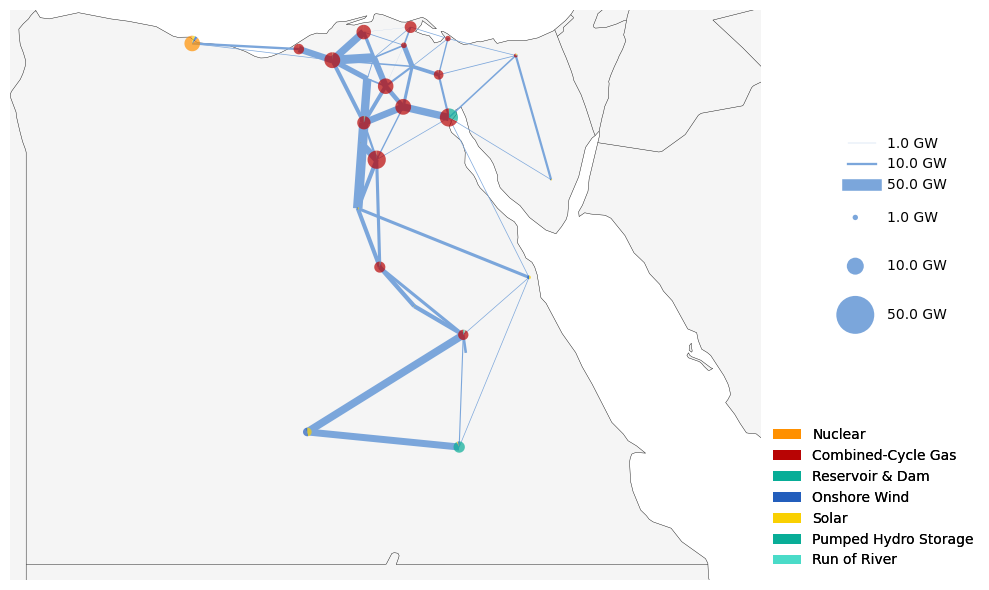

In [11]:
# Scale settings
bus_scale = 3e5 
line_scale = 6e3
link_scale = 6e25

bus_sizes = [1000, 10000, 50000]  # in MW
line_sizes = [1000, 10000, 50000]  # in MW

# --- Remove "Load" carrier for plotting ---
if "Load" in n.carriers.index:
    n.carriers.drop("Load", inplace=True)

# --- Aggregate generator and storage capacities by bus and carrier ---
gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()
buses = pd.concat([gen, sto])

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# --- Filter Links: only those that lie within GADM regions ---
# Extract the base part of the bus names
link_bus0_base = n.links.bus0.str.split("_AC").str[0]
link_bus1_base = n.links.bus1.str.split("_AC").str[0]

# Keep only links whose both ends are present in the GADM shapes
valid_links = n.links[
    link_bus0_base.isin(gadm_shapes.index) &
    link_bus1_base.isin(gadm_shapes.index) &
    (n.links.p_nom > 0)  # optional: only positive capacity
]

# overwrite temporarily for the plot
links_backup = n.links
n.links = valid_links

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom / line_scale,
        # link_widths=n.links.p_nom / line_scale,
        link_widths=0,
        line_colors="#7ba6db",
        ax=ax,
        margin=0.4,
        color_geomap={'ocean': 'white', 'land': 'whitesmoke'},
    )

# Set plot bounds (custom for Egypt)
bounds = regions_onshore.total_bounds.copy()
pad_x = 2 # expansion to the east
bounds[2] += pad_x  # expand east
ax.set_extent(bounds[[0, 2, 1, 3]])

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1.1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    patch_kw={'facecolor':'#7ba6db'},
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    colors=["#7ba6db"] * len(line_sizes),
    legend_kw={"bbox_to_anchor": (1.1, 0.8), **legend_kwargs},
)

# --- Create patch legend for carriers (unique nice_name, non-zero capacity) ---
colors_legend = []
labels_legend = []
seen = set()
for c in n.carriers.index:
    name = n.carriers.loc[c, 'nice_name']
    color = n.carriers.loc[c, 'color']

    # Sum capacity over all buses for this carrier
    if c in buses.index.get_level_values('carrier'):
        val_total = buses.xs(c, level='carrier').sum()
    else:
        val_total = 0

    if name not in seen and val_total > 0:
        seen.add(name)
        colors_legend.append(color)
        labels_legend.append(name)

add_legend_patches(
    ax,
    colors_legend,
    labels_legend,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc": "lower left"},
)

fig.tight_layout()

# Ensure the directory exists
output_dir = f"pypsa-earth-docu/results/EG/graphics_general/"
os.makedirs(output_dir, exist_ok=True)

# Save figure without white borders
if save_figs:
    filename = f"{output_dir}{overall_name}_brownfield_network.pdf"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    filename_png = filename.replace('.pdf', '.png')
    plt.savefig(filename_png, bbox_inches='tight', dpi=300)

plt.show()

<Axes: >

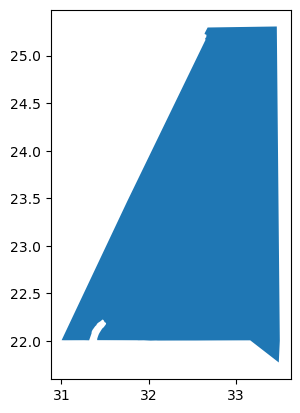

In [12]:
gadm_shapes[gadm_shapes.index == 'EG.17_1'].plot()

<Axes: xlabel='StorageUnit'>

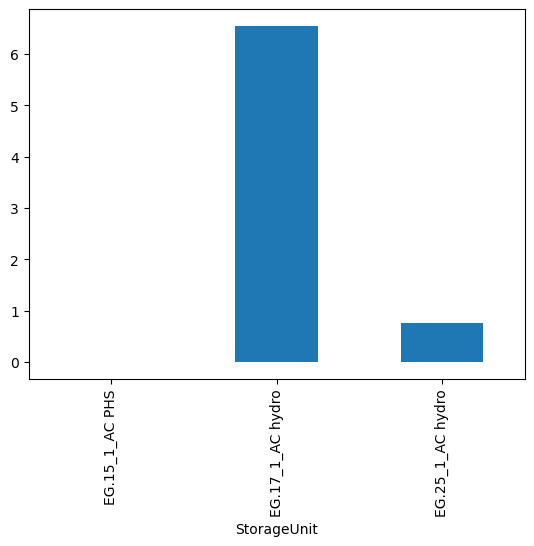

In [13]:
(((n.storage_units_t.p)*n.snapshot_weightings.generators.mean()).sum(axis=0) / 1e6).plot(kind='bar')

<Axes: xlabel='Line'>

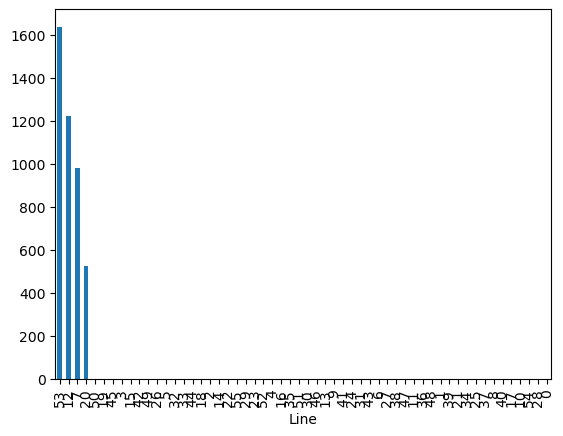

In [14]:
(n.lines.s_nom_opt - n.lines.s_nom).sort_values(ascending=False).plot(kind='bar')

Analyse the current generation capacity of the energy system - pie chart view

Text(0.5, 1.0, 'Generator Capacity by Carrier (GW)')

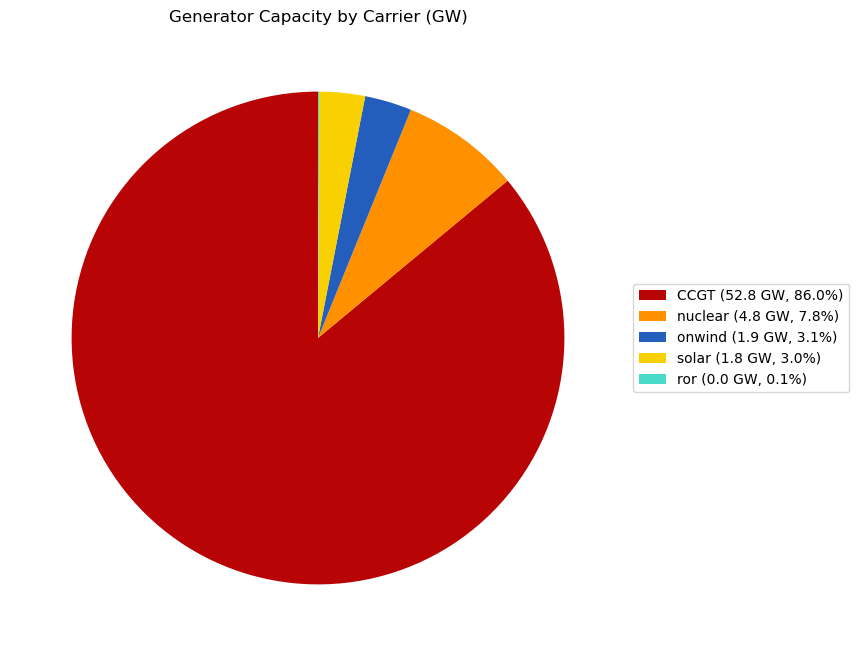

In [15]:
# --- Extract data for current energy carriers ---
generator_capacity_by_carrier = (
    n.generators[~n.generators.carrier.str.contains("load", case=False)]
    .groupby("carrier")
    .p_nom.sum()
    .div(1e3)  # Convert to GW
    .sort_values(ascending=False)
)
# --- Filter: keep only entries > 0 ---
generator_capacity_by_carrier = generator_capacity_by_carrier[generator_capacity_by_carrier > 0]

plt.figure(figsize=(8, 8))
wedges, _ = plt.pie(
    generator_capacity_by_carrier,
    labels=None,   # no labels directly in the chart
    startangle=90,
    colors=n.carriers[
            n.carriers.index.isin(generator_capacity_by_carrier.index)
        ].color.reindex(generator_capacity_by_carrier.index)
)
# Legend with capacity + share
labels = [
    f"{c} ({v:.1f} GW, {100*v/generator_capacity_by_carrier.sum():.1f}%)"
    for c, v in zip(generator_capacity_by_carrier.index, generator_capacity_by_carrier.values)
]
plt.legend(
    wedges,
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)
plt.title("Generator Capacity by Carrier (GW)")

Analyse the current generation capacity of the energy system - tabular view

In [16]:
generator_capacity_by_carrier # already in GW

carrier
CCGT       52.764200
nuclear     4.800000
onwind      1.889971
solar       1.836000
ror         0.047323
Name: p_nom, dtype: float64

Analyse the future capacity of the energy system - map view

<Axes: xlabel='bus,carrier'>

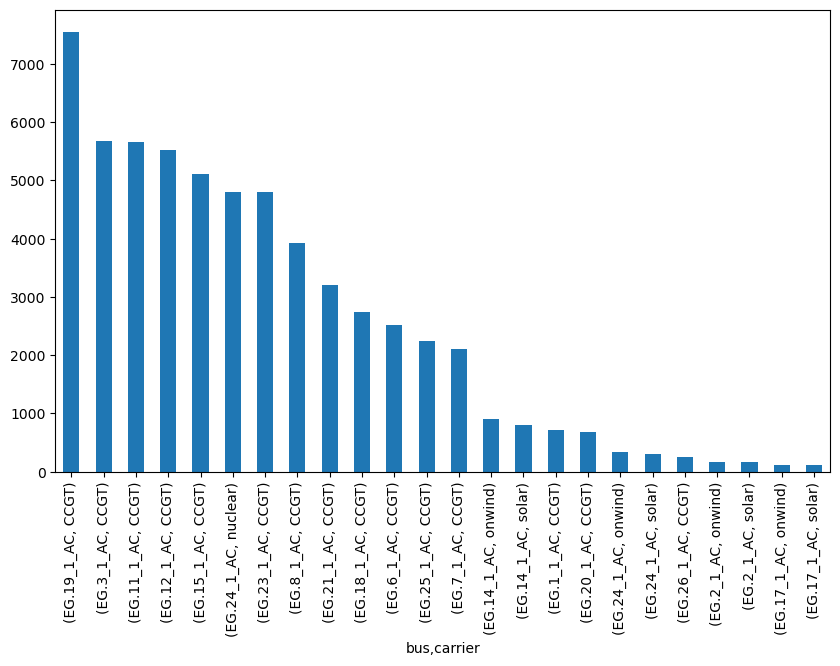

In [17]:
gen[gen > 100].sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))

### Analyse the future capacity of the energy system - map view

Add missing colors

In [18]:
# TODO: Ensure that every carrier has a color and a nice name in the config, then we can delete this code cell
mask_name = n.carriers["nice_name"].isna() | (n.carriers["nice_name"] == "")
n.carriers.loc[mask_name, "nice_name"] = n.carriers.index[mask_name].str.capitalize()

mask_color = n.carriers["color"].isna() | (n.carriers["color"] == "")
n.carriers.loc[mask_color, "color"] = "gray"

Plot the network

/opt/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


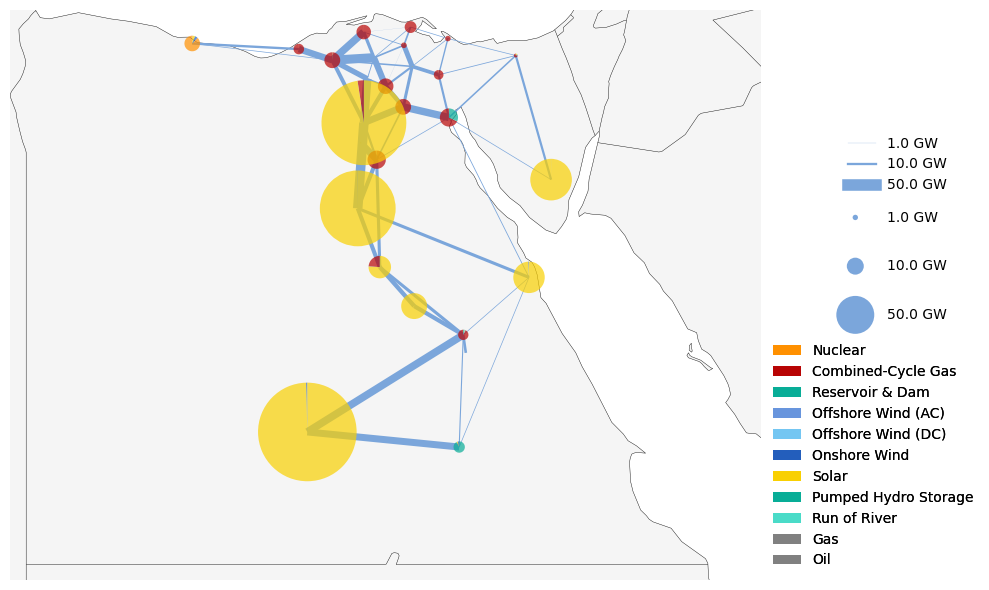

In [19]:
# Scale settings
bus_scale = 3e5 
line_scale = 6e3
link_scale = 6e25

bus_sizes = [1000, 10000, 50000]  # in MW
line_sizes = [1000, 10000, 50000]  # in MW

# --- Remove "Load" carrier for plotting ---
if "Load" in n.carriers.index:
    n.carriers.drop("Load", inplace=True)

# --- Aggregate generator and storage capacities by bus and carrier ---
gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom_opt.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
buses = pd.concat([gen, sto])

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# --- Filter Links: only those that lie within GADM regions ---
# Extract the base part of the bus names
link_bus0_base = n.links.bus0.str.split("_AC").str[0]
link_bus1_base = n.links.bus1.str.split("_AC").str[0]

# Keep only links whose both ends are present in the GADM shapes
valid_links = n.links[
    link_bus0_base.isin(gadm_shapes.index) &
    link_bus1_base.isin(gadm_shapes.index) &
    (n.links.p_nom > 0)  # optional: only positive capacity
]

# overwrite temporarily for the plot
links_backup = n.links
n.links = valid_links

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        # link_widths=n.links.p_nom_opt / line_scale,
        link_widths=0,
        line_colors="#7ba6db",
        ax=ax,
        margin=0.4,
        color_geomap={'ocean': 'white', 'land': 'whitesmoke'},
    )

# Set plot bounds (custom for Egypt)
bounds = regions_onshore.total_bounds.copy()
pad_x = 2 # expansion to the east
bounds[2] += pad_x  # expand east
ax.set_extent(bounds[[0, 2, 1, 3]])

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1.1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    patch_kw={'facecolor':'#7ba6db'},
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    colors=["#7ba6db"] * len(line_sizes),
    legend_kw={"bbox_to_anchor": (1.1, 0.8), **legend_kwargs},
)

# --- Create patch legend for carriers (unique nice_name, non-zero capacity) ---
colors_legend = []
labels_legend = []
seen = set()
for c in n.carriers.index:
    name = n.carriers.loc[c, 'nice_name']
    color = n.carriers.loc[c, 'color']

    # Sum capacity over all buses for this carrier
    if c in buses.index.get_level_values('carrier'):
        val_total = buses.xs(c, level='carrier').sum()
    else:
        val_total = 0

    if name not in seen and val_total > 0:
        seen.add(name)
        colors_legend.append(color)
        labels_legend.append(name)

add_legend_patches(
    ax,
    colors_legend,
    labels_legend,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc": "lower left"},
)

fig.tight_layout()

# Ensure the directory exists
output_dir = f"pypsa-earth-docu/results/EG/graphics_general/"
os.makedirs(output_dir, exist_ok=True)

# Save figure without white borders
if save_figs:
    filename = f"{output_dir}{overall_name}_optimized_network.pdf"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    filename_png = filename.replace('.pdf', '.png')
    plt.savefig(filename_png, bbox_inches='tight', dpi=300)

plt.show()

Analyse grid expansion

/opt/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


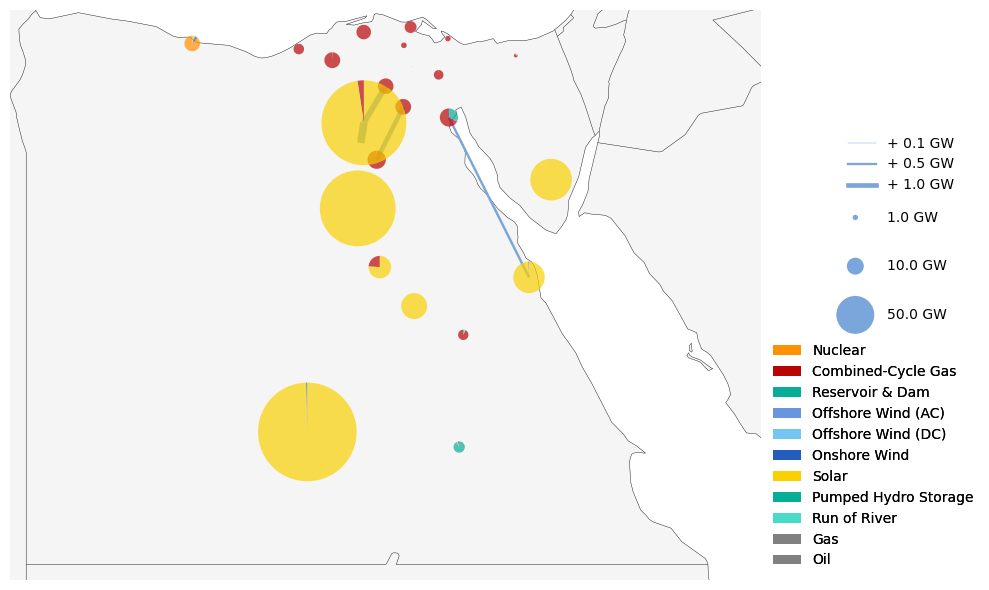

In [20]:
# Scale settings
bus_scale = 3e5 
line_scale = 3e2
link_scale = 6e25

bus_sizes = [1000, 10000, 50000]  # in MW
line_sizes = [100, 500, 1000]  # in MW

# --- Remove "Load" carrier for plotting ---
if "Load" in n.carriers.index:
    n.carriers.drop("Load", inplace=True)

# --- Aggregate generator and storage capacities by bus and carrier ---
gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom_opt.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
buses = pd.concat([gen, sto])

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# --- Filter Links: only those that lie within GADM regions ---
# Extract the base part of the bus names
link_bus0_base = n.links.bus0.str.split("_AC").str[0]
link_bus1_base = n.links.bus1.str.split("_AC").str[0]

# Keep only links whose both ends are present in the GADM shapes
valid_links = n.links[
    link_bus0_base.isin(gadm_shapes.index) &
    link_bus1_base.isin(gadm_shapes.index) &
    (n.links.p_nom > 0)  # optional: only positive capacity
]

# overwrite temporarily for the plot
links_backup = n.links
n.links = valid_links

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=(n.lines.s_nom_opt - n.lines.s_nom) / line_scale,
        # link_widths=n.links.p_nom / line_scale,
        link_widths=0,
        line_colors="#7ba6db",
        ax=ax,
        margin=0.4,
        color_geomap={'ocean': 'white', 'land': 'whitesmoke'},
    )

# Set plot bounds (custom for Egypt)
bounds = regions_onshore.total_bounds.copy()
pad_x = 2 # expansion to the east
bounds[2] += pad_x  # expand east
ax.set_extent(bounds[[0, 2, 1, 3]])

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1.1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    patch_kw={'facecolor':'#7ba6db'},
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"+ {s / 1000} GW" for s in line_sizes],
    colors=["#7ba6db"] * len(line_sizes),
    legend_kw={"bbox_to_anchor": (1.1, 0.8), **legend_kwargs},
)

# --- Create patch legend for carriers (unique nice_name, non-zero capacity) ---
colors_legend = []
labels_legend = []
seen = set()
for c in n.carriers.index:
    name = n.carriers.loc[c, 'nice_name']
    color = n.carriers.loc[c, 'color']

    # Sum capacity over all buses for this carrier
    if c in buses.index.get_level_values('carrier'):
        val_total = buses.xs(c, level='carrier').sum()
    else:
        val_total = 0

    if name not in seen and val_total > 0:
        seen.add(name)
        colors_legend.append(color)
        labels_legend.append(name)

add_legend_patches(
    ax,
    colors_legend,
    labels_legend,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc": "lower left"},
)

fig.tight_layout()

# Ensure the directory exists
output_dir = f"pypsa-earth-docu/results/EG/graphics_general/"
os.makedirs(output_dir, exist_ok=True)

# Save figure without white borders
if save_figs:
    filename = f"{output_dir}{overall_name}_optimized_network_GridExpansion.pdf"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    filename_png = filename.replace('.pdf', '.png')
    plt.savefig(filename_png, bbox_inches='tight', dpi=300)

plt.show()

## Plot multiple

In [21]:
# Assuming your .nc files live in elec_dir
elec_dir = "pypsa-earth/results/EG-sec-WS/postnetworks/"

# Collect all the .nc files
nc_files = [
    "elec_s_8_ec_lcopt_Co2L0-3H_24H_2050_0.071_NZ_0export.nc",
    "elec_s_8_ec_lcopt_Co2L0-3H_24H_2050_0.071_NZ_107export.nc",
    "elec_s_8_ec_lcopt_Co2L0.1-3H_24H_2050_0.071_NZ_0export.nc",
    "elec_s_8_ec_lcopt_Co2L0.1-3H_24H_2050_0.071_NZ_107export.nc",
    "elec_s_8_ec_lcopt_Co2L0.2-3H_24H_2050_0.071_NZ_0export.nc",
    "elec_s_8_ec_lcopt_Co2L0.2-3H_24H_2050_0.071_NZ_107export.nc",
    "elec_s_8_ec_lcopt_Co2L0.5-3H_24H_2050_0.071_NZ_0export.nc",
    "elec_s_8_ec_lcopt_Co2L0.5-3H_24H_2050_0.071_NZ_107export.nc",
    "elec_s_8_ec_lcopt_Co2L0.7-3H_24H_2050_0.071_NZ_0export.nc",
    "elec_s_8_ec_lcopt_Co2L0.7-3H_24H_2050_0.071_NZ_107export.nc",
]

# Prepare dicts
networks = {}
#regions_onshore = {}
gadm_regions = {}

# Loop and load
for f in nc_files:
    # Derive keys from filename
    base = os.path.splitext(f)[0]  # strip ".nc"
    parts = base.split("_")
    
    # Example: ["elec","s","8","ec","lcopt","Co2L0-3H","24H","2050","0.071","NZ","0export"]
    co2_policy = parts[5]   # e.g. "Co2L0.3-3H"
    export_policy = parts[-1]  # e.g. "0export" or "107export"
    
    key = co2_policy
    h2export_key = export_policy

    # Init dicts if not already
    if key not in networks:
        networks[key] = {}
        regions_onshore[key] = {}
        gadm_regions[key] = {}
    
    # Load PyPSA network
    path = os.path.join(elec_dir, f)
    networks[key][h2export_key] = pypsa.Network(path)
    
    #regions_onshore[key][h2export_key] = gpd.read_file(s["regions_onshore_path"])
    #gadm_regions[key][h2export_key] = gpd.read_file(s["gadm_path"])


Index(['CO2 pipeline EG.10_1_AC <-> EG.18_1_AC',
       'CO2 pipeline EG.10_1_AC <-> EG.19_1_AC',
       'CO2 pipeline EG.10_1_AC <-> EG.2_1_AC',
       'CO2 pipeline EG.10_1_AC <-> EG.8_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.12_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.15_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.16_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.19_1_AC',
       'CO2 pipeline EG.11_1_AC <-> EG.8_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.16_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.1_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.5_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.8_1_AC',
       'CO2 pipeline EG.12_1_AC <-> EG.9_1_AC',
       'CO2 pipeline EG.13_1_AC <-> EG.25_1_AC',
       'CO2 pipeline EG.14_1_AC <-> EG.17_1_AC',
       'CO2 pipeline EG.14_1_AC <-> EG.25_1_AC',
       'CO2 pipeline EG.15_1_AC <-> EG.19_1_AC',
       'CO2 pipeline EG.15_1_AC <-> EG.22_1_AC',
       'CO2 pipeline EG.15_1_AC <-> EG.26_1_AC',
       'CO2 pipeline EG.15_

### Electricity grid expansion

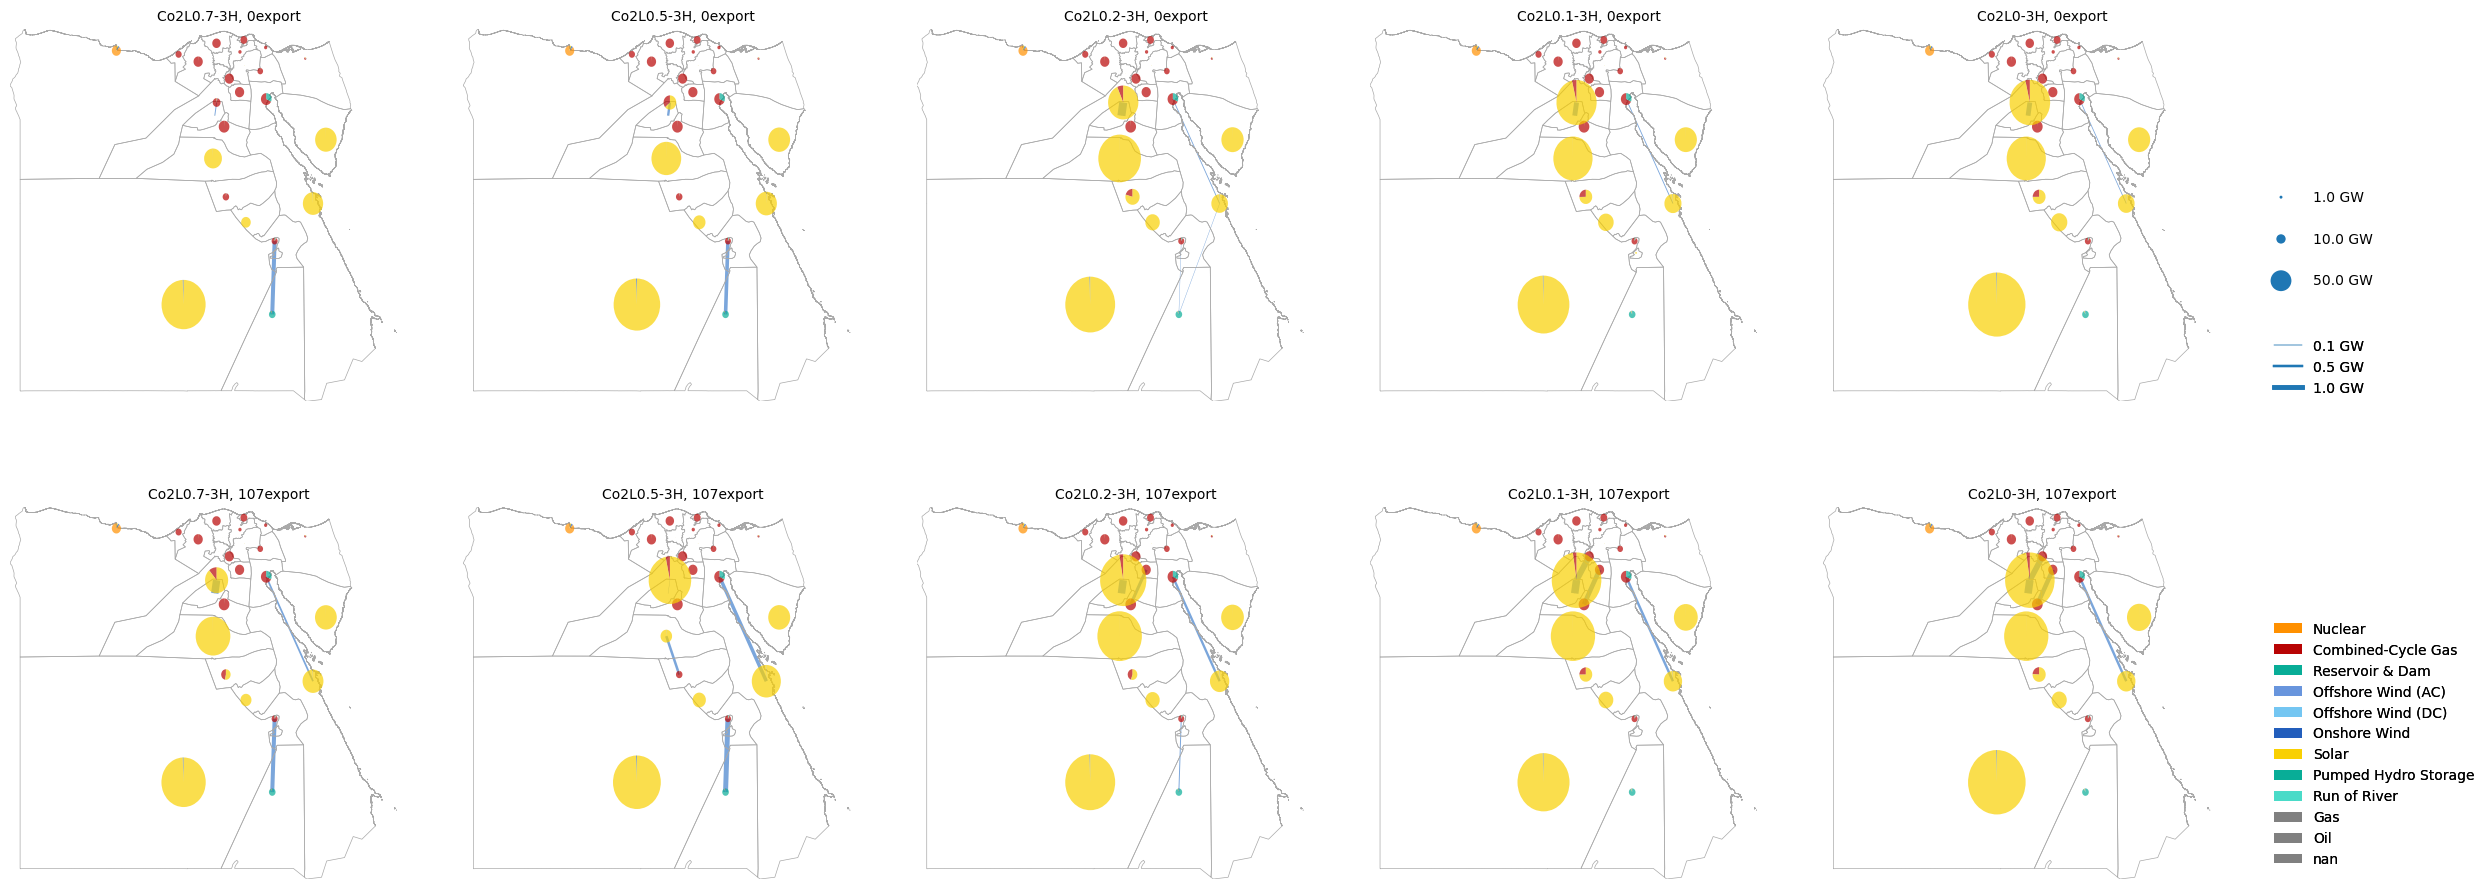

In [22]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# --- Setup subplot grid (2 x 5) ---
nrows, ncols = 2, 5
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(5*ncols, 5*nrows),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
axes = axes.flatten()

# --- Iterate over all networks in the dict ---
# Ensure each export scenario is plotted in its own row
export_keys = list(next(iter(networks.values())).keys())
for j, export_key in enumerate(export_keys):
    co2_keys = list(networks.keys())[::-1]  # reverse the ordering of the columns
    for i, co2_key in enumerate(co2_keys):
        idx = j * len(co2_keys) + i
        if idx >= len(axes):
            break
        n = networks[co2_key][export_key]
        ax = axes[idx]

        # --- Carrier fixes ---
        carrier_color_mapping = {
            'lignite': 'coal',
            'solar rooftop': 'solar',
            'residential rural solar thermal': 'solar',
            'residential urban decentral solar thermal': 'solar',
            'services rural solar thermal': 'solar',
            'services urban decentral solar thermal': 'solar',
            'urban central solar thermal': 'solar',
            'ccgt': 'gas'
        }

        for c, ref in carrier_color_mapping.items():
            if c in n.carriers.index and ref in n.carriers.index:
                n.carriers.loc[c, 'color'] = n.carriers.loc[ref, 'color']

        if "coal" in n.carriers.index:
            n.carriers.loc['coal', 'nice_name'] = 'Coal'
        if "oil" in n.carriers.index:
            n.carriers.loc['oil', 'nice_name'] = 'Oil'
        if "ccgt" in n.carriers.index:
            n.carriers.loc['ccgt', 'nice_name'] = 'Gas'

        for c, ref in carrier_color_mapping.items():
            if c in n.carriers.index and c != 'ccgt' and ref in n.carriers.index:
                n.carriers.loc[c, 'nice_name'] = n.carriers.loc[ref, 'nice_name']

        if "Load" in n.carriers.index:
            n.carriers.drop("Load", inplace=True)

        mask_name = n.carriers["nice_name"].isna() | (n.carriers["nice_name"] == "")
        n.carriers.loc[mask_name, "nice_name"] = n.carriers.index[mask_name].str.capitalize()
        mask_color = n.carriers["color"].isna() | (n.carriers["color"] == "")
        n.carriers.loc[mask_color, "color"] = "gray"

        # --- Capacities ---
        gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom_opt.sum()
        sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
        buses = pd.concat([gen, sto])

        # --- Scale settings ---
        bus_scale = 3e5
        line_scale = 3e2
        bus_sizes = [1000, 10000, 50000]
        line_sizes = [100, 500, 1000]

        # --- Filter links ---
        link_bus0_base = n.links.bus0.str.split("_AC").str[0]
        link_bus1_base = n.links.bus1.str.split("_AC").str[0]
        valid_links = n.links[
            link_bus0_base.isin(gadm_shapes.index)
            & link_bus1_base.isin(gadm_shapes.index) # MUST BE = GADM_ID
            # & link_bus1_base.isin(gadm_shapes.GADM_ID)
            & (n.links.p_nom > 0)
        ]

        n.links = valid_links

        missing = n.carriers[n.carriers["color"].isna() | (n.carriers["color"].str.strip() == "")]
        if not missing.empty:
            print(f"⚠️ {co2_key}/{export_key}: Missing colors for {list(missing.index)}")

        missing_carriers = set(buses.index.get_level_values("carrier")) - set(n.carriers.index)
        for c in missing_carriers:
            n.carriers.loc[c, "color"] = "gray"

        # --- Plot ---
        with plt.rc_context({"patch.linewidth": 0.}):
            n.plot(
                bus_sizes=buses / bus_scale,
                bus_alpha=0.7,
                line_widths=(n.lines.s_nom_opt - n.lines.s_nom) / line_scale,
                link_widths=0,
                line_colors="#7ba6db",
                ax=ax,
                margin=0.4,
                # color_geomap={'ocean': 'white', 'land': 'whitesmoke'},
                color_geomap = False
            )

        # --- Bounds ---
        bounds = regions_onshore.total_bounds.copy()
        pad_x = 2
        bounds[2] += pad_x
        ax.set_extent(bounds[[0, 2, 1, 3]])

        # Show gadm region borders
        gadm_shapes.boundary.plot(ax=ax, edgecolor='darkgrey', linewidth=0.5, zorder=3)

        # --- Title per subplot ---
        ax.set_title(f"{co2_key}, {export_key}", fontsize=10)

# --- Add legends ---
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.6), "labelspacing": 2.0, **legend_kwargs}

add_legend_circles(
    axes[4],
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    axes[4],
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.2), **legend_kwargs},
)

# --- Create patch legend for carriers (unique nice_name, non-zero capacity) ---
colors_legend = []
labels_legend = []
seen = set()
for c in n.carriers.index:
    name = n.carriers.loc[c, 'nice_name']
    color = n.carriers.loc[c, 'color']

    # Sum capacity over all buses for this carrier
    if c in buses.index.get_level_values('carrier'):
        val_total = buses.xs(c, level='carrier').sum()
    else:
        val_total = 0

    if name not in seen and val_total > 0:
        seen.add(name)
        colors_legend.append(color)
        labels_legend.append(name)

add_legend_patches(
    ax,
    colors_legend,
    labels_legend,
    legend_kw={"bbox_to_anchor": (1, -0), **legend_kwargs, "loc": "lower left"},
)

# --- Adjust layout ---
fig.tight_layout()

# Ensure the directory exists
output_dir = f"pypsa-earth-docu/results/EG/graphics_general/"
os.makedirs(output_dir, exist_ok=True)

# Save figure without white borders
if save_figs:
    filename = f"{output_dir}{overall_name}_all_networks_grid-expansion.pdf"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    filename_png = filename.replace('.pdf', '.png')
    plt.savefig(filename_png, bbox_inches='tight', dpi=300)

plt.show()

## Plot multiple - plot hydrogen generation

In [23]:
electrolysis_links = {}

# --- Iterate over all networks in the dict ---
export_keys = list(next(iter(networks.values())).keys())
for j, export_key in enumerate(export_keys):
    co2_keys = list(networks.keys())[::-1]  # reverse the ordering of the columns
    for i, co2_key in enumerate(co2_keys):
        idx = j * len(co2_keys) + i
        if idx >= len(axes):
            break
        n = networks[co2_key][export_key]
        net = networks[key][h2export_key]
        mask = net.links.carrier == "H2 Electrolysis"
        electrolysis_links.setdefault(key, {})[h2export_key] = net.links.loc[mask].copy()

net.links
        

,bus0,bus1,carrier,p_nom_extendable,efficiency,capital_cost,bus2,bus3,bus4,efficiency2,...,start_up_cost,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down
Link,,,,,,,,,,,,,,,,,,,,,
EG.11_1_AC oil,EG.11_1_AC oil,EG.11_1_AC,oil,False,0.35,13677.398163,co2 atmosphere,,,0.2571,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
EG.18_1_AC oil,EG.18_1_AC oil,EG.18_1_AC,oil,False,0.35,13677.398163,co2 atmosphere,,,0.2571,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
EG.19_1_AC oil,EG.19_1_AC oil,EG.19_1_AC,oil,False,0.35,13677.398163,co2 atmosphere,,,0.2571,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
EG.22_1_AC oil,EG.22_1_AC oil,EG.22_1_AC,oil,False,0.35,13677.398163,co2 atmosphere,,,0.2571,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
EG.24_1_AC oil,EG.24_1_AC oil,EG.24_1_AC,oil,False,0.35,13677.398163,co2 atmosphere,,,0.2571,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EG.5_1_AC V2G,EG.5_1_AC EV battery,EG.5_1_AC low voltage,V2G,False,0.90,0.000000,,,,1.0000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
EG.6_1_AC V2G,EG.6_1_AC EV battery,EG.6_1_AC low voltage,V2G,False,0.90,0.000000,,,,1.0000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
EG.7_1_AC V2G,EG.7_1_AC EV battery,EG.7_1_AC low voltage,V2G,False,0.90,0.000000,,,,1.0000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0


In [24]:
for i in electrolysis_links.keys():
    for j in electrolysis_links[i].keys():
        print(f"Key 1: {i}, Key 2: {j}\n")

Key 1: Co2L0.7-3H, Key 2: 107export



### Extract electrolysis data

In [25]:
electrolysis_links = {}

for key in networks:
    for h2export_key in networks[key]:
        # if 'electrolysis_links' not in locals():
        #     electrolysis_links = {}
        # if key not in electrolysis_links:
        #     electrolysis_links[key] = {}
        net = networks[key][h2export_key]
        mask = net.links.carrier == "H2 Electrolysis"
        electrolysis_links.setdefault(key, {})[h2export_key] = net.links.loc[mask].copy()

### Get time series of links and map them to their buses

In [26]:
electrolysis_results = {}

for key in electrolysis_links:
    electrolysis_results[key] = {}
    for h2export_key in electrolysis_links[key]:
        # Get electrolysis links and network
        links = electrolysis_links[key][h2export_key]
        net = networks[key][h2export_key]

        # Get time series for these links
        electrolysis_ts = net.links_t.p1[links.index]

        # Map links to their buses
        electrolysis_bus_map = links.bus0

        # Group and sum electrolysis by bus over time
        electrolysis_by_bus_ts = electrolysis_ts.T.groupby(electrolysis_bus_map).sum().T * net.snapshot_weightings.generators.mean()

        # Sum over time to get total electrolysis per bus
        total_electrolysis_per_bus = electrolysis_by_bus_ts.sum() / 1e6  # Convert to TWh

        # Save all info in nested dict
        electrolysis_results[key][h2export_key] = {
            "links": links,
            "network": net,
            "electrolysis_ts": electrolysis_ts,
            "bus_map": electrolysis_bus_map,
            "by_bus_ts": electrolysis_by_bus_ts,
            "total_per_bus": total_electrolysis_per_bus
        }

### Plot hydrogen generation per scenario

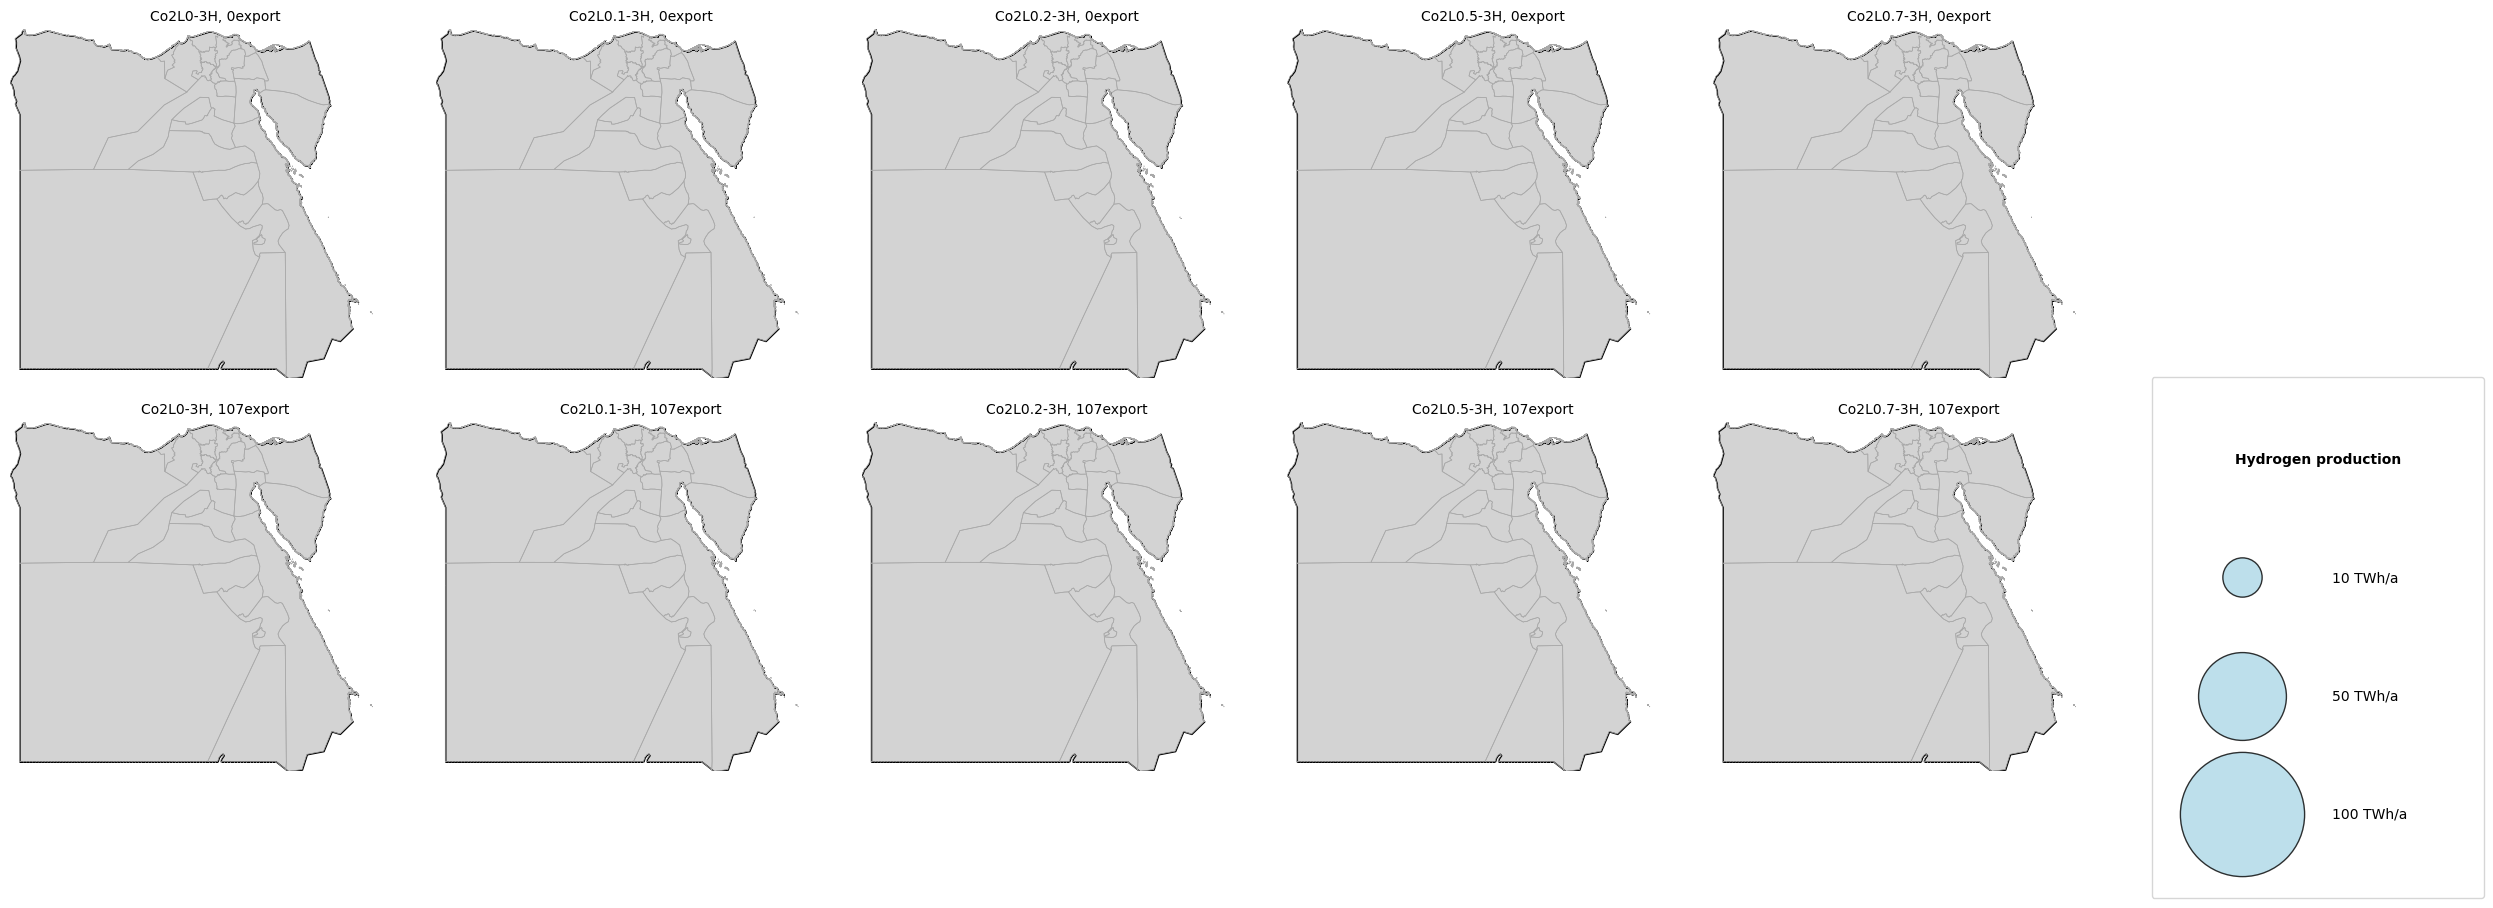

In [27]:
# Plot hydrogen electrolysis per bus for all scenarios in one figure

# --- Setup subplot grid (2 x 5) ---
nrows, ncols = 2, 5
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(5*ncols, 5*nrows),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
axes = axes.flatten()

# num_scenarios = sum(len(electrolysis_results[key]) for key in electrolysis_results)
# fig, axs = plt.subplots(1, num_scenarios, figsize=(6 * num_scenarios, 6), squeeze=False)

co2_keys = list(networks.keys())
export_keys = list(next(iter(networks.values())).keys())
for j, export_key in enumerate(export_keys):
    for i, co2_key in enumerate(co2_keys):
        idx = j * len(co2_keys) + i
        if idx >= len(axes):
            break
        ax = axes[idx]
        result = electrolysis_results[co2_key][export_key]
        total_electrolysis_per_bus = result["total_per_bus"].abs()
        bus_coords = result["network"].buses[["x", "y"]]
        bus_coords_electrolysis = bus_coords.loc[total_electrolysis_per_bus.index]
        sizes = total_electrolysis_per_bus * 90  # scale for visibility

        ax = axes[idx]
        # Use the correct regions_onshore for each scenario
        # if key in regions_onshore and h2export_key in regions_onshore[key]:
        #     regions_onshore[key][h2export_key].plot(ax=ax, color="lightgrey", edgecolor="black")
        # else:
        regions_onshore.plot(ax=ax, color="lightgrey", edgecolor="black")

        sc = ax.scatter(
            bus_coords_electrolysis["x"],
            bus_coords_electrolysis["y"],
            s=sizes,
            #c=total_electrolysis_per_bus,
            color="lightblue",
            alpha=0.8,
            edgecolor="k"
        )

        # --- Bounds ---
        bounds = regions_onshore.total_bounds.copy()
        pad_x = 2
        bounds[2] += pad_x
        ax.set_extent(bounds[[0, 2, 1, 3]])

        # Show gadm region borders
        gadm_shapes.boundary.plot(ax=ax, edgecolor='darkgrey', linewidth=0.5, zorder=3)
        # --- Title per subplot ---
        ax.set_title(f"{co2_key}, {export_key}", fontsize=10)
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])
        i += 1

# Add a legend for electrolysis capacity
legend_electrolysis_caps = [10, 50, 100]
legend_electrolysis_sizes = np.array(legend_electrolysis_caps) * 80  # same scaling as 'sizes'
legend_electrolysis = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue',
               markersize=np.sqrt(s), label=f'{cap} TWh/a', alpha=0.8, markeredgecolor='k')
    for cap, s in zip(legend_electrolysis_caps, legend_electrolysis_sizes)
]
plt.legend(handles=legend_electrolysis, title="Hydrogen production", bbox_to_anchor=(1.05, 1.15), loc='upper left', labelspacing=7.5, handletextpad=5.5, borderpad=5.5)
plt.setp(plt.gca().get_legend().get_title(), fontweight='bold')
plt.tight_layout()

# Ensure the directory exists
output_dir = f"pypsa-earth-docu/results/EG/graphics_general/"
os.makedirs(output_dir, exist_ok=True)

# Save figure without white borders
if save_figs:
    filename = f"{output_dir}{overall_name}_all_networks_h2-gen.pdf"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    filename_png = filename.replace('.pdf', '.png')
    plt.savefig(filename_png, bbox_inches='tight', dpi=300)

plt.show()

plt.show()


### Prepare pipeline data

In [28]:
from shapely.geometry import LineString

# --- Extract and save all scenario data in nested dicts ---
scenario_keys = list(networks.keys())
h2export_keys = list(networks[scenario_keys[0]].keys())

buses = {}
lines = {}
capacity = {}
lines_gdf = {}
buses_gdf = {}
line_widths = {}
h2_pipelines_rep = {}

# Define min and max capacity for normalization
cap_min = 0  # in MW
cap_max = 1000  # in MW

for scenario in scenario_keys:
    buses[scenario] = {}
    lines[scenario] = {}
    capacity[scenario] = {}
    lines_gdf[scenario] = {}
    buses_gdf[scenario] = {}
    line_widths[scenario] = {}
    h2_pipelines_rep[scenario] = {}
    for h2export_key in h2export_keys:
        # Filter for repurposed H2 pipelines only
        h2_pipelines_rep[scenario][h2export_key] = networks[scenario][h2export_key].links[
            networks[scenario][h2export_key].links.carrier == "H2 pipeline repurposed"
        ].copy()

        # Buses
        buses[scenario][h2export_key] = networks[scenario][h2export_key].buses.copy()
        buses_gdf[scenario][h2export_key] = gpd.GeoDataFrame(
            buses[scenario][h2export_key],
            geometry=gpd.points_from_xy(
                buses[scenario][h2export_key].x,
                buses[scenario][h2export_key].y
            ),
            crs="EPSG:4326"
        )

        # Pipelines
        def build_pipeline_geometry(row):
            x0, y0 = networks[scenario][h2export_key].buses.loc[row.bus0, ["x", "y"]]
            x1, y1 = networks[scenario][h2export_key].buses.loc[row.bus1, ["x", "y"]]
            return LineString([(x0, y0), (x1, y1)])

        pipelines_rep_temp = h2_pipelines_rep[scenario][h2export_key].copy()
        pipelines_rep = pipelines_rep_temp.copy()
        pipelines_rep["geometry"] = None  # Initialize geometry column first
        pipelines_rep["geometry"] = pipelines_rep_temp.apply(build_pipeline_geometry, axis=1)
        # Write geometry into the original dict as well
        h2_pipelines_rep[scenario][h2export_key]["geometry"] = pipelines_rep["geometry"]
        lines_gdf[scenario][h2export_key] = gpd.GeoDataFrame(pipelines_rep, geometry="geometry", crs="EPSG:4326")

        # Normalize pipeline widths by capacity
        if 'p_nom_opt' in lines_gdf[scenario][h2export_key].columns:
            capacity[scenario][h2export_key] = lines_gdf[scenario][h2export_key]["p_nom_opt"]
            line_widths[scenario][h2export_key] = np.interp(
                capacity[scenario][h2export_key],
                (cap_min, cap_max),
                (1.5, 9.0)
            )
        else:
            line_widths[scenario][h2export_key] = [1.5] * len(lines_gdf[scenario][h2export_key])

ValueError: Columns must be same length as key

In [ ]:
import re

def split_co2_key(co2_key):
    # Example: "Co2L0.7-3H" -> 0.7
    match = re.search(r'L(.*?)-', co2_key)
    return float(match.group(1)) if match else None

# Example usage:
split_values = [split_co2_key(key) for key in scenario_keys]
print(split_values)

In [ ]:
def split_export_key(export_key):
    # Example: "107export" -> 107.0
    split_val = export_key.split("e")[0]
    split_val_float = float(split_val) if split_val else 0
    return np.round(split_val_float, 2)

split_export_key('107export')

### Extract hydrogen demand per bus

In [ ]:
# Extract h2 demand per bus
h2_demand_per_bus = {}
for co2_key in networks.keys():
    for export_key in networks[co2_key].keys():
        result = electrolysis_results[co2_key][export_key]
        # Select all links where bus1 contains 'H2' and exclude storage units/stores
        net = result["network"]
        # Exclude links whose carrier contains 'storage' or 'store' (case-insensitive)
        h2_links_mask = (
            net.links.bus1.str.contains("H2", case=False)
            & ~net.links.carrier.str.contains("storage|store", case=False)
        )
        h2_links = net.links[h2_links_mask]
        # Get time series for these links
        h2_links_ts = net.links_t.p1[h2_links.index]
        # Sum energy over time for each link, then sum over all links to get total per bus0
        total_h2_energy_per_bus = h2_links_ts.sum() * net.snapshot_weightings.generators.mean() / 1e6  # TWh
        # Group by bus0 (origin bus)
        total_h2_energy_per_bus_by_bus0 = h2_links.groupby("bus0").apply(
            lambda df: total_h2_energy_per_bus[df.index].sum()
        )
        total_h2_demand_per_bus = total_h2_energy_per_bus_by_bus0.abs()
        h2_demand_per_bus[(co2_key, export_key)] = total_h2_demand_per_bus
        # Map to buses_gdf
        # Add h2 demand to buses_gdf, aligning index
        buses_gdf[co2_key][export_key] = buses_gdf[co2_key][export_key].copy()
        # Ensure total_h2_demand_per_bus is a Series and not empty
        if not total_h2_demand_per_bus.empty:
            buses_gdf[co2_key][export_key]["h2_demand_TWh"] = total_h2_demand_per_bus.reindex(buses_gdf[co2_key][export_key].index).fillna(0)
        else:
            buses_gdf[co2_key][export_key]["h2_demand_TWh"] = 0


### Plot h2 gen + pipelines

In [ ]:
import matplotlib.lines as mlines

# Plot hydrogen electrolysis per bus for all scenarios in one figure

# --- Setup subplot grid (2 x 5) ---
nrows, ncols = 2, 5
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(5*ncols, 5*nrows),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
axes = axes.flatten()

# num_scenarios = sum(len(electrolysis_results[key]) for key in electrolysis_results)
# fig, axs = plt.subplots(1, num_scenarios, figsize=(6 * num_scenarios, 6), squeeze=False)

for co2_key in networks.keys():
    for export_key in networks[co2_key].keys():
        # Calculate subplot index for each scenario
        idx = list(networks.keys()).index(co2_key) + len(networks) * list(networks[co2_key].keys()).index(export_key)
        if idx >= len(axes):
            break
        ax = axes[idx]
        result = electrolysis_results[co2_key][export_key]
        total_electrolysis_per_bus = result["total_per_bus"].abs()
        bus_coords = result["network"].buses[["x", "y"]]
        bus_coords_electrolysis = bus_coords.loc[total_electrolysis_per_bus.index]
        sizes = total_electrolysis_per_bus * 50  # scale for visibility

        ax = axes[idx]
        # Use the correct regions_onshore for each scenario
        # if key in regions_onshore and h2export_key in regions_onshore[key]:
        #     regions_onshore[key][h2export_key].plot(ax=ax, color="lightgrey", edgecolor="black")
        # else:
        regions_onshore.plot(ax=ax, color="lightgrey", edgecolor="black")

        sc = ax.scatter(
            bus_coords_electrolysis["x"],
            bus_coords_electrolysis["y"],
            s=sizes,
            #c=total_electrolysis_per_bus,
            color="lightblue",
            alpha=0.8,
            edgecolor="k"
        )

        # Plot pipelines for this scenario and h2export_key
        if co2_key in lines_gdf and export_key in lines_gdf[co2_key]:
            for geom, width in zip(lines_gdf[co2_key][export_key].geometry, line_widths[co2_key][export_key]):
                ax.add_geometries([geom], crs=ccrs.PlateCarree(),
                                  linewidth=width, edgecolor="#206bc7", facecolor='none', zorder=2, linestyle='-', capstyle='round')

        # Plot buses
        if co2_key in buses_gdf and export_key in buses_gdf[co2_key]:
            ax.scatter(
                buses_gdf[co2_key][export_key].geometry.x,
                buses_gdf[co2_key][export_key].geometry.y,
                s=5,
                color='black',
                zorder=3,
                transform=ccrs.PlateCarree()
            )

        # --- Bounds ---
        bounds = regions_onshore.total_bounds.copy()
        pad_x = 2
        bounds[2] += pad_x
        # Extend above
        pad_y = 1.3
        bounds[3] += pad_y
        bounds[1] -= 0.5*pad_y
        ax.set_extent(bounds[[0, 2, 1, 3]])

        # Show gadm region borders
        gadm_shapes.boundary.plot(ax=ax, edgecolor='darkgrey', linewidth=0.5, zorder=3)
        # --- Title per subplot ---
        ax.set_title(
            f"CO2 Reduction: {int(split_co2_key(co2_key)*100)} %, H2 Export: {int(split_export_key(export_key))} TWh/a",
            fontsize=12
        )
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])
        i += 1

# -----------------------------
# Legend 1: Pipeline capacity
legend_caps = [1000, 10000, 20000, 40000]  # in MW
legend_widths = np.interp(legend_caps, (cap_min, cap_max), (1.5, 9.0))
legend_lines = [
    mlines.Line2D([], [], color='#206bc7', linewidth=lw, label=f'{cap / 1000:.1f} GW')
    for cap, lw in zip(legend_caps, legend_widths)
]

legend1 = fig.legend(
    handles=legend_lines,
    title="Pipeline capacity",
    loc="upper center",           # anchor refers to top-center
    bbox_to_anchor=(0.2, 0),   # (x, y) in figure coords
    fontsize=20,
    ncol=len(legend_lines),
    borderpad=2.4,
    labelspacing=4.0,
    title_fontproperties={"weight": "bold"}
)

# -----------------------------
# Legend 2: Hydrogen production
legend_electrolysis_caps = [10, 50, 100]
legend_electrolysis_sizes = np.array(legend_electrolysis_caps) * 100
legend_electrolysis = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="lightblue",
        markersize=np.sqrt(s),
        label=label,
        alpha=0.8,
        markeredgecolor="k",
    )
    for s, label in zip(legend_electrolysis_sizes, [
        "10 TWh/a   ",
        "    50 TWh/a      ",
        "        100 TWh/a   "
    ])
]

legend2 = fig.legend(
    handles=legend_electrolysis,
    title="Hydrogen production",
    loc="upper center",
    bbox_to_anchor=(0.7, 0),
    fontsize=20,
    ncol=len(legend_electrolysis),
    borderpad=2.4,
    labelspacing=4.0,
    handletextpad=0.9,
    title_fontproperties={"weight": "bold"}
)

# # Add a legend for electrolysis capacity
# legend_electrolysis_caps = [10, 50, 100]
# legend_electrolysis_sizes = np.array(legend_electrolysis_caps) * 50  # same scaling as 'sizes'
# legend_electrolysis = [
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue',
#                markersize=np.sqrt(s), label=f'{cap} TWh/a', alpha=0.8, markeredgecolor='k')
#     for cap, s in zip(legend_electrolysis_caps, legend_electrolysis_sizes)
# ]
# plt.legend(handles=legend_electrolysis, title="Hydrogen production", bbox_to_anchor=(1.05, 1.15), loc='upper left', labelspacing=7.5, handletextpad=3.5, borderpad=4.5)
# plt.setp(plt.gca().get_legend().get_title(), fontweight='bold')

# # Add legend for pipeline capacity
# legend_caps = [100, 500, 10000]  # in MW
# legend_widths = np.interp(legend_caps, (cap_min, cap_max), (1.5, 9.0))
# legend_lines = [
#     mlines.Line2D([], [], color='#206bc7', linewidth=lw, label=f'{cap / 1000:.1f} GW')
#     for cap, lw in zip(legend_caps, legend_widths)
# ]
# # Add legend below all plots, centered
# fig.legend(handles=legend_lines, title='Pipeline capacity', loc='lower center', fontsize=20, ncol=len(legend_lines), bbox_to_anchor=(0.5, -0.1))


plt.tight_layout()

# Ensure the directory exists
output_dir = f"pypsa-earth-docu/results/EG/graphics_general/"
os.makedirs(output_dir, exist_ok=True)

# Save figure without white borders
if save_figs:
    filename = f"{output_dir}{overall_name}_all_networks_h2-gen+transport.pdf"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    filename_png = filename.replace('.pdf', '.png')
    plt.savefig(filename_png, bbox_inches='tight', dpi=300)

plt.show()


### Plot h2 gen + pipelines

In [ ]:
import matplotlib.lines as mlines

# Plot hydrogen electrolysis per bus for all scenarios in one figure

# --- Setup subplot grid (2 x 5) ---
nrows, ncols = 2, 5
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(5*ncols, 5*nrows),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
axes = axes.flatten()

# num_scenarios = sum(len(electrolysis_results[key]) for key in electrolysis_results)
# fig, axs = plt.subplots(1, num_scenarios, figsize=(6 * num_scenarios, 6), squeeze=False)

for co2_key in networks.keys():
    for export_key in networks[co2_key].keys():
        # Calculate subplot index for each scenario
        idx = list(networks.keys()).index(co2_key) + len(networks) * list(networks[co2_key].keys()).index(export_key)
        if idx >= len(axes):
            break
        ax = axes[idx]
        result = electrolysis_results[co2_key][export_key]
        total_electrolysis_per_bus = result["total_per_bus"].abs()
        bus_coords = result["network"].buses[["x", "y"]]
        bus_coords_electrolysis = bus_coords.loc[total_electrolysis_per_bus.index]
        sizes = total_electrolysis_per_bus * 50  # scale for visibility

        ax = axes[idx]
        # Use the correct regions_onshore for each scenario
        # if key in regions_onshore and h2export_key in regions_onshore[key]:
        #     regions_onshore[key][h2export_key].plot(ax=ax, color="lightgrey", edgecolor="black")
        # else:
        regions_onshore.plot(ax=ax, color="lightgrey", edgecolor="black")

        # Plot hydrogen production per bus (lightblue)
        sc = ax.scatter(
            bus_coords_electrolysis["x"],
            bus_coords_electrolysis["y"],
            s=sizes,
            color="lightblue",
            alpha=0.8,
            edgecolor="k"
        )

        buses = buses_gdf[co2_key][export_key]
        # If 'h2_demand_TWh' column exists, plot it
        if "h2_demand_TWh" in buses.columns and not buses["h2_demand_TWh"].isnull().all():
            demand_bus_coords = buses.geometry
            demand_sizes = buses["h2_demand_TWh"].fillna(0) * 1  # scale for visibility
            ax.scatter(
                demand_bus_coords.x,
                demand_bus_coords.y,
                s=demand_sizes,
                color="lightcoral",
                alpha=0.8,
                edgecolor="k",
                zorder=3,
                transform=ccrs.PlateCarree()
            )

            # Assign hydrogen demand per bus if available, else set to zero
            if not total_h2_demand_per_bus.empty:
                buses_gdf[co2_key][export_key]["h2_demand_TWh"] = (
                    total_h2_demand_per_bus.set_index("bus0").reindex(buses_gdf[co2_key][export_key].index)["p_nom"].fillna(0)
                )
            else:
                buses_gdf[co2_key][export_key]["h2_demand_TWh"] = 0

        # Plot pipelines for this scenario and h2export_key
        if co2_key in lines_gdf and export_key in lines_gdf[co2_key]:
            for geom, width in zip(lines_gdf[co2_key][export_key].geometry, line_widths[co2_key][export_key]):
                ax.add_geometries([geom], crs=ccrs.PlateCarree(),
                                  linewidth=width, edgecolor="#206bc7", facecolor='none', zorder=2, linestyle='-', capstyle='round')

        # Plot buses
        if co2_key in buses_gdf and export_key in buses_gdf[co2_key]:
            ax.scatter(
                buses_gdf[co2_key][export_key].geometry.x,
                buses_gdf[co2_key][export_key].geometry.y,
                s=5,
                color='black',
                zorder=3,
                transform=ccrs.PlateCarree()
            )

        # --- Bounds ---
        bounds = regions_onshore.total_bounds.copy()
        pad_x = 2
        bounds[2] += pad_x
        # Extend above
        pad_y = 1.3
        bounds[3] += pad_y
        bounds[1] -= 0.5*pad_y
        ax.set_extent(bounds[[0, 2, 1, 3]])

        # Show gadm region borders
        gadm_shapes.boundary.plot(ax=ax, edgecolor='darkgrey', linewidth=0.5, zorder=3)
        # --- Title per subplot ---
        ax.set_title(
            f"CO2 Reduction: {int(split_co2_key(co2_key)*100)} %, H2 Export: {int(split_export_key(export_key))} TWh/a",
            fontsize=12
        )
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])
        i += 1

# -----------------------------
# Legend 1: Pipeline capacity
legend_caps = [1000, 10000, 20000, 40000]  # in MW
legend_widths = np.interp(legend_caps, (cap_min, cap_max), (1.5, 9.0))
legend_lines = [
    mlines.Line2D([], [], color='#206bc7', linewidth=lw, label=f'{cap / 1000:.1f} GW')
    for cap, lw in zip(legend_caps, legend_widths)
]

legend1 = fig.legend(
    handles=legend_lines,
    title="Pipeline capacity",
    loc="upper center",           # anchor refers to top-center
    bbox_to_anchor=(0.2, 0),   # (x, y) in figure coords
    fontsize=20,
    ncol=len(legend_lines),
    borderpad=2.4,
    labelspacing=4.0,
    title_fontproperties={"weight": "bold"}
)

# -----------------------------
# Legend 2: Hydrogen production
legend_electrolysis_caps = [10, 50, 100]
legend_electrolysis_sizes = np.array(legend_electrolysis_caps) * 100
legend_electrolysis = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="lightblue",
        markersize=np.sqrt(s),
        label=label,
        alpha=0.8,
        markeredgecolor="k",
    )
    for s, label in zip(legend_electrolysis_sizes, [
        "10 TWh/a   ",
        "    50 TWh/a      ",
        "        100 TWh/a   "
    ])
]

legend2 = fig.legend(
    handles=legend_electrolysis,
    title="Hydrogen production",
    loc="upper center",
    bbox_to_anchor=(0.7, 0),
    fontsize=20,
    ncol=len(legend_electrolysis),
    borderpad=2.4,
    labelspacing=4.0,
    handletextpad=0.9,
    title_fontproperties={"weight": "bold"}
)

# # Add a legend for electrolysis capacity
# legend_electrolysis_caps = [10, 50, 100]
# legend_electrolysis_sizes = np.array(legend_electrolysis_caps) * 50  # same scaling as 'sizes'
# legend_electrolysis = [
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue',
#                markersize=np.sqrt(s), label=f'{cap} TWh/a', alpha=0.8, markeredgecolor='k')
#     for cap, s in zip(legend_electrolysis_caps, legend_electrolysis_sizes)
# ]
# plt.legend(handles=legend_electrolysis, title="Hydrogen production", bbox_to_anchor=(1.05, 1.15), loc='upper left', labelspacing=7.5, handletextpad=3.5, borderpad=4.5)
# plt.setp(plt.gca().get_legend().get_title(), fontweight='bold')

# # Add legend for pipeline capacity
# legend_caps = [100, 500, 10000]  # in MW
# legend_widths = np.interp(legend_caps, (cap_min, cap_max), (1.5, 9.0))
# legend_lines = [
#     mlines.Line2D([], [], color='#206bc7', linewidth=lw, label=f'{cap / 1000:.1f} GW')
#     for cap, lw in zip(legend_caps, legend_widths)
# ]
# # Add legend below all plots, centered
# fig.legend(handles=legend_lines, title='Pipeline capacity', loc='lower center', fontsize=20, ncol=len(legend_lines), bbox_to_anchor=(0.5, -0.1))


plt.tight_layout()

# Ensure the directory exists
output_dir = f"pypsa-earth-docu/results/EG/graphics_general/"
os.makedirs(output_dir, exist_ok=True)

# Save figure without white borders
if save_figs:
    filename = f"{output_dir}{overall_name}_all_networks_h2-gen+transport_DemandInProgress.pdf"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    filename_png = filename.replace('.pdf', '.png')
    plt.savefig(filename_png, bbox_inches='tight', dpi=300)

plt.show()


In [ ]:
type(split_co2_key(co2_key))

In [ ]:
networks['Co2L0-3H']['107export'].links.loc[
	networks['Co2L0-3H']['107export'].links.carrier.str.contains("H2 pipeline")
].p_nom_opt.sort_values(ascending=False)

In [ ]:
temp_links = networks['Co2L0.7-3H']['0export'].links.p_nom_opt - networks['Co2L0.7-3H']['0export'].links.p_nom
temp_links = temp_links[temp_links > 300].sort_values(ascending=False)
temp_links.plot(kind='bar')

## Plot multiple - pipelines

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# --- Setup subplot grid (2 x 5) ---
nrows, ncols = 2, 5
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(5*ncols, 5*nrows),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
axes = axes.flatten()

# --- Iterate over all networks in the dict ---
for i, (co2_key, export_dict) in enumerate(networks.items()):
    for j, (export_key, n) in enumerate(export_dict.items()):
        idx = i*len(export_dict) + j
        if idx >= len(axes):
            break
        ax = axes[idx]

        # --- Carrier fixes ---
        carrier_color_mapping = {
            'lignite': 'coal',
            'solar rooftop': 'solar',
            'residential rural solar thermal': 'solar',
            'residential urban decentral solar thermal': 'solar',
            'services rural solar thermal': 'solar',
            'services urban decentral solar thermal': 'solar',
            'urban central solar thermal': 'solar',
            'ccgt': 'gas'
        }

        for c, ref in carrier_color_mapping.items():
            if c in n.carriers.index and ref in n.carriers.index:
                n.carriers.loc[c, 'color'] = n.carriers.loc[ref, 'color']

        if "coal" in n.carriers.index:
            n.carriers.loc['coal', 'nice_name'] = 'Coal'
        if "oil" in n.carriers.index:
            n.carriers.loc['oil', 'nice_name'] = 'Oil'
        if "ccgt" in n.carriers.index:
            n.carriers.loc['ccgt', 'nice_name'] = 'Gas'

        for c, ref in carrier_color_mapping.items():
            if c in n.carriers.index and c != 'ccgt' and ref in n.carriers.index:
                n.carriers.loc[c, 'nice_name'] = n.carriers.loc[ref, 'nice_name']

        if "Load" in n.carriers.index:
            n.carriers.drop("Load", inplace=True)

        mask_name = n.carriers["nice_name"].isna() | (n.carriers["nice_name"] == "")
        n.carriers.loc[mask_name, "nice_name"] = n.carriers.index[mask_name].str.capitalize()
        mask_color = n.carriers["color"].isna() | (n.carriers["color"] == "")
        n.carriers.loc[mask_color, "color"] = "gray"

        # --- Capacities ---
        gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom_opt.sum()
        sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
        buses = pd.concat([gen, sto])

        # --- Scale settings ---
        bus_scale = 3e5
        line_scale = 3e2
        bus_sizes = [1000, 10000, 50000]
        line_sizes = [100, 500, 1000]

        # --- Filter links ---
        link_bus0_base = n.links.bus0.str.split("_AC").str[0]
        link_bus1_base = n.links.bus1.str.split("_AC").str[0]
        valid_links = n.links[
            link_bus0_base.isin(gadm_shapes.index)
            # & link_bus1_base.isin(gadm_shapes.index)
            & link_bus1_base.isin(gadm_shapes.index)
            & (n.links.p_nom > 0)
        ]

        n.links = valid_links

        missing = n.carriers[n.carriers["color"].isna() | (n.carriers["color"].str.strip() == "")]
        if not missing.empty:
            print(f"⚠️ {co2_key}/{export_key}: Missing colors for {list(missing.index)}")

        missing_carriers = set(buses.index.get_level_values("carrier")) - set(n.carriers.index)
        for c in missing_carriers:
            n.carriers.loc[c, "color"] = "gray"

        # --- Plot ---
        with plt.rc_context({"patch.linewidth": 0.}):
            n.plot(
                bus_sizes=buses / bus_scale,
                bus_alpha=0.7,
                # line_widths=(n.lines.s_nom_opt - n.lines.s_nom) / line_scale,
                line_widths = 0,
                link_widths = (n.links.p_nom_opt - n.links.p_nom) / line_scale,
                line_colors="#7ba6db",
                ax=ax,
                margin=0.4,
                color_geomap={'ocean': 'white', 'land': 'whitesmoke'},
            )

        # --- Bounds ---
        bounds = regions_onshore.total_bounds.copy()
        pad_x = 2
        bounds[2] += pad_x
        ax.set_extent(bounds[[0, 2, 1, 3]])

        # --- Title per subplot ---
        ax.set_title(f"{co2_key}, {export_key}", fontsize=10)

# --- Adjust layout ---
fig.tight_layout()

# Ensure the directory exists
output_dir = f"pypsa-earth-docu/results/EG/graphics_general/"
os.makedirs(output_dir, exist_ok=True)

# Save figure without white borders
if save_figs:
    filename = f"{output_dir}{overall_name}_all_networks_pipeline-expansion.pdf"
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    filename_png = filename.replace('.pdf', '.png')
    plt.savefig(filename_png, bbox_inches='tight', dpi=300)

plt.show()


In [ ]:
networks.keys()

## Dispatch

In [ ]:
# Import 3H res network
net_3H = pypsa.Network('pypsa-earth/results/EG-sec-WS/postnetworks/elec_s_12_ec_lcopt_Co2L-3H_3H_2050_0.071_NZ_400export.nc')
n = net_3H.copy()

# Select one week in October
october_week = n.snapshots[(n.snapshots.month == 10) & (n.snapshots.day >= 7) & (n.snapshots.day <= 13)]

# Filter buses for AC buses only
ac_buses = n.buses[n.buses.carrier.str.contains("AC", case=False)].index

# Get generator dispatch for AC buses
dispatch = n.generators_t.p.loc[october_week, n.generators[n.generators.bus.isin(ac_buses)].index]

# Get storage_unit dispatch for AC buses
dispatch_storage = n.storage_units_t.p.loc[october_week, n.storage_units[n.storage_units.bus.isin(ac_buses)].index]

# Combine generator and storage dispatch
dispatch = pd.concat([dispatch, dispatch_storage], axis=1).fillna(0)

# Group dispatch by carrier
dispatch_by_carrier = dispatch.groupby(carrier_map, axis=1).sum()

# Plot stacked line plot
fig, ax = plt.subplots(figsize=(12, 6))
dispatch_by_carrier.plot.area(ax=ax, stacked=True)
ax.set_title("AC Bus Dispatch by Carrier (One Week in October)")
ax.set_ylabel("Power [MW]")
ax.set_xlabel("Time")
plt.legend(title="Carrier", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [ ]:
dispatch_storage

## Plot current capacities

In [ ]:
# --- Extract data for current energy carriers ---
generator_capacity_by_carrier = (
    n.generators[~n.generators.carrier.str.contains("load", case=False)]
    .groupby("carrier")
    .p_nom.sum()
    .div(1e3)  # Convert to GW
    .sort_values(ascending=False)
)
# --- Filter: keep only entries > 0 ---
generator_capacity_by_carrier = generator_capacity_by_carrier[generator_capacity_by_carrier > 0]

plt.figure(figsize=(8, 8))
wedges, _ = plt.pie(
    generator_capacity_by_carrier,
    labels=None,   # no labels directly in the chart
    startangle=90,
    colors=n.carriers[
            n.carriers.index.isin(generator_capacity_by_carrier.index)
        ].color.reindex(generator_capacity_by_carrier.index)
)
# Legend with capacity + share
labels = [
    f"{c} ({v:.1f} GW, {100*v/generator_capacity_by_carrier.sum():.1f}%)"
    for c, v in zip(generator_capacity_by_carrier.index, generator_capacity_by_carrier.values)
]
plt.legend(
    wedges,
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)
plt.title("Generator Capacity by Carrier (GW)")

## Analyse loads (updated)

In [ ]:
n.loads.carrier.unique()

In [ ]:
loads_sum = (
    n.loads_t.p
    .groupby([n.loads.bus, n.loads.carrier], axis=1)
    .sum()
    .mul(n.snapshot_weightings.generators.mean())
    .sum()
)
loads_sum[loads_sum.abs() > 1e6].divide(1e6).sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))

In [ ]:
n.statistics.energy_balance(comps='Load').divide(-1e6).sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))

In [ ]:
# Fix: Use get_level_values to filter MultiIndex by 'heat' in any level
energy_balance_load = n.statistics.energy_balance(comps='Load')
mask = energy_balance_load.index.to_frame().apply(lambda row: row.astype(str).str.contains('heat').any(), axis=1)
energy_balance_load[mask].divide(-1e6).sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))

In [ ]:
# Fix: Use get_level_values to filter MultiIndex by 'transport' in any level
energy_balance_load = n.statistics.energy_balance(comps='Load')
mask = energy_balance_load.index.to_frame().apply(lambda row: row.astype(str).str.contains('transport').any(), axis=1)
energy_balance_load[mask].divide(-1e6).sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))

Analys the future generation capacity expansion of the energy system - bar chart

In [ ]:
optimal_capacity = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)
installed_capacity = n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion = optimal_capacity - installed_capacity
generation_capacity_expansion.drop(["load"], inplace=True)
generation_capacity_expansion.plot.bar(title="Generator capacity expansion in GW")

Plot the future generation capacity expansion of the energy system - tabular chart

In [ ]:
generation_capacity_expansion # In GW

Analyse the future energy generation of the energy system - bar chart view

In [ ]:
colors = {key.lower(): value.lower() for key, value in config["plotting"]["tech_colors"].items()}
nice_names = {value.lower(): key for key, value in config["plotting"]["nice_names"].items()}

rename_cols = {
    '-': 'Load',
    'load': 'load shedding',
}

energy_balance = (
    n.statistics.energy_balance()
    .loc[:, :, "AC"]
    .groupby("carrier")
    .sum()
    .div(1e6)
    .to_frame()
    .T
    .rename(columns=rename_cols)
)

# color-matching
color_list = []
for col in energy_balance.columns:
    original_name = col.lower()
    key_name = nice_names.get(original_name, original_name)
    color = colors.get(key_name.lower(), 'gray')
    color_list.append(color)


fig, ax = plt.subplots()
energy_balance.plot.bar(stacked=True, ax=ax, title="Energy Balance in TWh", color=color_list)
handles, labels = ax.get_legend_handles_labels()
nice_labels = [config["plotting"]["nice_names"].get(label, label) for label in energy_balance.columns]
ax.legend(handles, nice_labels, bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)

plt.show()

Analyse the future energy generation of the energy system - tabular view

In [ ]:
n.statistics.energy_balance()/1e6 # In TWh

## Analyse pv and wind potential - map view

In [29]:
solar = xr.open_dataset(solar_path)
wind = xr.open_dataset(onwind_path)

def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None):
    g = n.generators.loc[n.generators.carrier == carrier]
    br = gpd.read_file(f"{PARENT}resources/{scenario_name}/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br_area = br.to_crs("ESRI:54009")
    br_area = br_area.geometry.area * 1e-6
    br["p_nom_max"] = g.groupby("bus").sum().p_nom_max / br_area

    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
    plt.rcParams.update({"font.size": 10})
    br.plot(
        ax=ax,
        column="p_nom_max",
        transform=ccrs.PlateCarree(),
        linewidth=0.25,
        edgecolor="k",
        cmap=cmap,
        vmin=0,
        vmax=br["p_nom_max"].max(),
        legend=True,
        legend_kwds={"label": r"potential density"},
    )
    ax.coastlines()
    regions_onshore.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=0.5,
        transform=ccrs.PlateCarree(),
    )
    #ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
    ax.set_extent(country_coordinates, crs=ccrs.PlateCarree()) 
    
    if title is not None:
        plt.title(title)

Plot wind energy potential

Index(['transf_1_0', 'transf_1_1', 'transf_2_0', 'transf_2_1', 'transf_3_0',
       'transf_4_0', 'transf_5_0', 'transf_6_0', 'transf_8_0', 'transf_9_0',
       ...
       'transf_351_0', 'transf_352_0', 'transf_354_0', 'transf_359_0',
       'transf_361_0', 'transf_362_0', 'transf_369_0', 'transf_369_1',
       'transf_376_0', 'transf_417_0'],
      dtype='object', name='name', length=164)
Index(['transf_1_0', 'transf_1_1', 'transf_2_0', 'transf_2_1', 'transf_3_0',
       'transf_4_0', 'transf_5_0', 'transf_6_0', 'transf_8_0', 'transf_9_0',
       ...
       'transf_351_0', 'transf_352_0', 'transf_354_0', 'transf_359_0',
       'transf_361_0', 'transf_362_0', 'transf_369_0', 'transf_369_1',
       'transf_376_0', 'transf_417_0'],
      dtype='object', name='name', length=164)
Index(['transf_1_0', 'transf_1_1', 'transf_2_0', 'transf_2_1', 'transf_3_0',
       'transf_4_0', 'transf_5_0', 'transf_6_0', 'transf_8_0', 'transf_9_0',
       ...
       'transf_351_0', 'transf_352_0', 'transf_

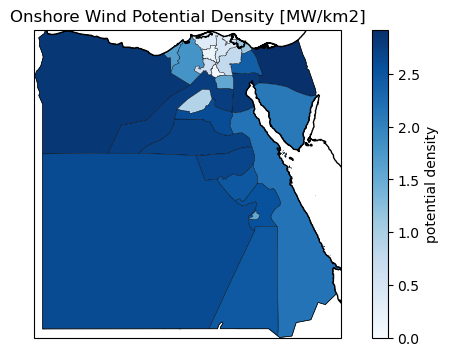

In [30]:
warnings.simplefilter(action='ignore', category=FutureWarning)
scenario_name = run_name
plot_voronoi(
    pypsa.Network(network_path),
    "onwind",
    "onshore",
    "Blues",
    ccrs.PlateCarree(),
    title="Onshore Wind Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Plot pv energy potential

Index(['transf_1_0', 'transf_1_1', 'transf_2_0', 'transf_2_1', 'transf_3_0',
       'transf_4_0', 'transf_5_0', 'transf_6_0', 'transf_8_0', 'transf_9_0',
       ...
       'transf_351_0', 'transf_352_0', 'transf_354_0', 'transf_359_0',
       'transf_361_0', 'transf_362_0', 'transf_369_0', 'transf_369_1',
       'transf_376_0', 'transf_417_0'],
      dtype='object', name='name', length=164)
Index(['transf_1_0', 'transf_1_1', 'transf_2_0', 'transf_2_1', 'transf_3_0',
       'transf_4_0', 'transf_5_0', 'transf_6_0', 'transf_8_0', 'transf_9_0',
       ...
       'transf_351_0', 'transf_352_0', 'transf_354_0', 'transf_359_0',
       'transf_361_0', 'transf_362_0', 'transf_369_0', 'transf_369_1',
       'transf_376_0', 'transf_417_0'],
      dtype='object', name='name', length=164)
Index(['transf_1_0', 'transf_1_1', 'transf_2_0', 'transf_2_1', 'transf_3_0',
       'transf_4_0', 'transf_5_0', 'transf_6_0', 'transf_8_0', 'transf_9_0',
       ...
       'transf_351_0', 'transf_352_0', 'transf_

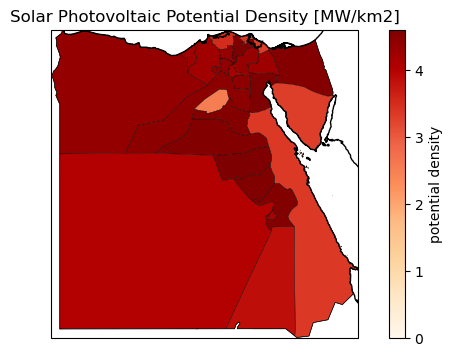

In [31]:
warnings.simplefilter(action='ignore', category=FutureWarning)
scenario_name = run_name
plot_voronoi(
    pypsa.Network(network_path),
    "solar",
    "onshore",
    "OrRd",
    ccrs.PlateCarree(),
    title="Solar Photovoltaic Potential Density [MW/km2]"
)
warnings.simplefilter(action='default', category=FutureWarning)